# FIFA Player Performance and Market Value
## Project 1

---
### Team Members

| Name                  | ID       |
|-----------------------|----------|
| Ismail Ahmed          | 16002979 |
| Maleeka Sabek         | 16003638 |
| Ritag Mohamed Hussein | 16005509 |
| Nour Eldin Ashraf     | 16009532 |

---



In [102]:
import numpy as np
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load dataset from Google Drive
df = pd.read_csv('/content/drive/MyDrive/fifa_player_performance_market_value.csv')
df.head(10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium
3,4,Player_4,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,Yes,Medium
4,5,Player_5,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,No,Low
5,6,Player_6,37,Argentina,Manchester City,CM,92,91,35,9,7,263,98.51,5,Yes,Low
6,7,Player_7,23,Netherlands,Liverpool,RB,72,66,53,24,6,4299,67.69,1,No,Low
7,8,Player_8,35,Spain,Bayern Munich,LW,69,97,8,34,17,3101,24.71,0,No,Low
8,9,Player_9,39,Brazil,FC Barcelona,GK,83,90,21,24,23,2106,127.50,3,Yes,High
9,10,Player_10,27,England,Liverpool,LB,69,92,0,28,5,3080,146.55,1,No,High


In [103]:
# Display first 12 rows
df.head(12)

,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium
3,4,Player_4,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,Yes,Medium
4,5,Player_5,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,No,Low
5,6,Player_6,37,Argentina,Manchester City,CM,92,91,35,9,7,263,98.51,5,Yes,Low
6,7,Player_7,23,Netherlands,Liverpool,RB,72,66,53,24,6,4299,67.69,1,No,Low
7,8,Player_8,35,Spain,Bayern Munich,LW,69,97,8,34,17,3101,24.71,0,No,Low
8,9,Player_9,39,Brazil,FC Barcelona,GK,83,90,21,24,23,2106,127.50,3,Yes,High
9,10,Player_10,27,England,Liverpool,LB,69,92,0,28,5,3080,146.55,1,No,High


In [104]:
# Display last 12 rows
df.tail(12)

,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
2788,2789,Player_2789,38,Argentina,FC Barcelona,ST,70,88,53,36,22,1066,2.78,3,Yes,Medium
2789,2790,Player_2790,29,Argentina,Bayern Munich,GK,80,94,44,2,0,2146,66.86,0,No,Medium
2790,2791,Player_2791,17,England,PSG,ST,89,72,38,39,3,705,46.68,2,No,Low
2791,2792,Player_2792,33,France,Juventus,CB,69,86,6,4,2,2358,102.46,1,No,Medium
2792,2793,Player_2793,22,Argentina,Manchester City,ST,85,89,3,27,3,3534,114.10,3,Yes,Medium
2793,2794,Player_2794,20,Portugal,PSG,LB,86,74,14,13,0,3812,179.96,0,No,Medium
2794,2795,Player_2795,36,Argentina,PSG,RW,67,93,11,38,11,2470,92.54,3,No,Low
2795,2796,Player_2796,32,Germany,Bayern Munich,CB,67,65,47,10,12,4067,99.49,3,No,Medium
2796,2797,Player_2797,31,Netherlands,Real Madrid,LB,67,85,5,7,1,3460,74.87,4,No,Low
2797,2798,Player_2798,31,Brazil,Manchester City,ST,93,88,8,36,8,3768,27.01,3,No,Medium


In [105]:
# Print shape of the dataset
print(df.shape)
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

(2800, 16)
The dataset has 2800 rows and 16 columns.


In [106]:
# Column names
df.columns

Index(['player_id', 'player_name', 'age', 'nationality', 'club', 'position',
       'overall_rating', 'potential_rating', 'matches_played', 'goals',
       'assists', 'minutes_played', 'market_value_million_eur',
       'contract_years_left', 'injury_prone', 'transfer_risk_level'],
      dtype='object')

In [107]:
# Data types
df.dtypes

,0
player_id,int64
player_name,object
age,int64
nationality,object
club,object
position,object
overall_rating,int64
potential_rating,int64
matches_played,int64
goals,int64


In [108]:
# Dataset info (non-null counts and data types)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 2800 non-null   int64  
 1   player_name               2800 non-null   object 
 2   age                       2800 non-null   int64  
 3   nationality               2800 non-null   object 
 4   club                      2800 non-null   object 
 5   position                  2800 non-null   object 
 6   overall_rating            2800 non-null   int64  
 7   potential_rating          2800 non-null   int64  
 8   matches_played            2800 non-null   int64  
 9   goals                     2800 non-null   int64  
 10  assists                   2800 non-null   int64  
 11  minutes_played            2800 non-null   int64  
 12  market_value_million_eur  2800 non-null   float64
 13  contract_years_left       2800 non-null   int64  
 14  injury_p

In [109]:
# Target variable: transfer_risk_level
# This column tells us how likely a player is to be transferred

# Class distribution
df['transfer_risk_level'].value_counts()
# Class distribution as percentage
(df['transfer_risk_level'].value_counts() / len(df)) * 100

,count
transfer_risk_level,
Low,44.642857
Medium,35.392857
High,19.964286


In [110]:
# Analyzing the 'position' column

# Distinct values
df['position'].unique()
# Number of unique values
df['position'].nunique()
# Most frequent value
df['position'].mode()[0]
# Full frequency breakdown
df['position'].value_counts()

,count
position,
ST,329
LW,328
LB,323
GK,317
CB,315
CDM,305
CM,302
RW,295
RB,286


In [111]:
# Summary statistics for all numerical features
df.describe()
# Mean of numerical features
df.mean(numeric_only=True)
# Median of numerical features
df.median(numeric_only=True)
# Standard deviation
df.std(numeric_only=True)
# Percentiles: 20%, 50%, 75%
df.quantile([0.20, 0.50, 0.75], numeric_only=True)

,player_id,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left
0.20,560.80,21.0,67.0,71.0,11.0,7.0,5.0,904.00,37.3580,1.0
0.50,1400.50,28.0,77.0,82.0,27.0,19.0,12.0,2251.00,89.1700,3.0
0.75,2100.25,34.0,85.0,90.0,41.0,30.0,18.0,3366.25,136.6825,4.0


In [112]:
# Check missing values per column
df.isnull().sum()
# Percentage of missing values
(df.isnull().sum() / len(df)) * 100


,0
player_id,0.0
player_name,0.0
age,0.0
nationality,0.0
club,0.0
position,0.0
overall_rating,0.0
potential_rating,0.0
matches_played,0.0
goals,0.0


In [113]:
# Check for duplicates
df.duplicated().sum()
# Remove duplicates if found
df = df.drop_duplicates()
df.shape

(2800, 16)

In [114]:
# Filter players with overall_rating >= 70
# This is relevant because low-rated players are unlikely to be transfer targets
df_filtered = df[df['overall_rating'] >= 70]
print(f"Rows before filter: {len(df)}")
print(f"Rows after filter: {len(df_filtered)}")

Rows before filter: 2800
Rows after filter: 2002


In [115]:
from sklearn.preprocessing import LabelEncoder

# Label encode binary column 'injury_prone' (Yes/No)
le = LabelEncoder()
df['injury_prone_encoded'] = le.fit_transform(df['injury_prone'])

# One-hot encode nominal columns
df = pd.get_dummies(df, columns=['nationality', 'club', 'position'])

print("Encoding done.")
df.shape

Encoding done.


(2800, 38)

In [116]:
from sklearn.preprocessing import StandardScaler

numerical_cols = ['age', 'overall_rating', 'potential_rating', 'matches_played',
                  'goals', 'assists', 'minutes_played', 'market_value_million_eur', 'contract_years_left']

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Normalization done.")
df[numerical_cols].head()

Normalization done.


,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left
0,-0.733814,-1.196328,0.557314,-1.197721,-1.146639,0.276186,0.560440,0.613496,0.277871
1,1.192401,1.324001,-0.570422,-0.509221,-1.406024,0.832733,0.277092,-0.040244,1.454937
2,0.451549,-0.188197,0.967400,0.429642,-0.627868,0.415323,-0.843172,-1.350606,0.277871
3,-0.141132,1.324001,0.454792,0.492232,-0.109096,0.137050,-1.625272,1.415884,-1.487726
4,-0.585644,0.719122,1.480007,0.867778,-1.146639,-0.836907,-0.018608,0.591026,0.866404


In [117]:
# Divide market_value_million_eur into 5 equal-width bins (before scaling, so use original)
# Reload original for binning display
df_original = pd.read_csv("fifa_player_performance_market_value.csv")

df_original['market_value_bin'] = pd.cut(df_original['market_value_million_eur'], bins=5)

print("Bin distribution:")
print(df_original['market_value_bin'].value_counts().sort_index())

Bin distribution:
market_value_bin
(0.491, 36.528]       548
(36.528, 72.386]      593
(72.386, 108.244]     535
(108.244, 144.102]    557
(144.102, 179.96]     567
Name: count, dtype: int64


In [118]:
# Check missing values
print(df.isnull().sum())

# No missing values found in this dataset
# If there were, we would use median for numerical (robust to outliers)
# and mode for categorical columns
print("No missing values to handle.")

player_id                   0
player_name                 0
age                         0
overall_rating              0
potential_rating            0
matches_played              0
goals                       0
assists                     0
minutes_played              0
market_value_million_eur    0
contract_years_left         0
injury_prone                0
transfer_risk_level         0
injury_prone_encoded        0
nationality_Argentina       0
nationality_Brazil          0
nationality_England         0
nationality_France          0
nationality_Germany         0
nationality_Netherlands     0
nationality_Portugal        0
nationality_Spain           0
club_Bayern Munich          0
club_FC Barcelona           0
club_Juventus               0
club_Liverpool              0
club_Manchester City        0
club_PSG                    0
club_Real Madrid            0
position_CB                 0
position_CDM                0
position_CM                 0
position_GK                 0
position_L

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation of numerical features with each other
corr_matrix = df[numerical_cols].corr()

# plt.figure(figsize=(10, 6))
# sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
# plt.title("Correlation Heatmap")
# plt.show()
plt.close()

# Features highly correlated with each other (>0.85) are candidates for removal
print(corr_matrix)

                               age  overall_rating  potential_rating  \
age                       1.000000        0.004680         -0.024240   
overall_rating            0.004680        1.000000         -0.008142   
potential_rating         -0.024240       -0.008142          1.000000   
matches_played            0.007983        0.033604          0.021164   
goals                    -0.004041       -0.016133         -0.026948   
assists                   0.007944       -0.023006         -0.006540   
minutes_played            0.013362       -0.034137         -0.047372   
market_value_million_eur -0.014363        0.013490         -0.006453   
contract_years_left      -0.034096       -0.044501          0.035675   

                          matches_played     goals   assists  minutes_played  \
age                             0.007983 -0.004041  0.007944        0.013362   
overall_rating                  0.033604 -0.016133 -0.023006       -0.034137   
potential_rating                0.02116

In [120]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

# Re-encode target for chi2
df_original = pd.read_csv("fifa_player_performance_market_value.csv")
le = LabelEncoder()
target = le.fit_transform(df_original['transfer_risk_level'])

# Use one-hot encoded position for chi2
position_dummies = pd.get_dummies(df_original['position'])

# Chi2 requires non-negative values
chi_scores, p_values = chi2(position_dummies, target)

chi_df = pd.DataFrame({'position': position_dummies.columns, 'chi2': chi_scores, 'p_value': p_values})
print(chi_df.sort_values('p_value'))

  position      chi2   p_value
5       LW  7.284920  0.026188
3       GK  4.173126  0.124113
4       LB  3.567534  0.168004
7       RW  2.979837  0.225391
0       CB  2.281820  0.319528
6       RB  1.559085  0.458616
2       CM  1.502854  0.471693
1      CDM  1.287419  0.525340
8       ST  0.556202  0.757220


In [121]:
# player_id and player_name are identifiers, not predictive features
df.drop(columns=['player_id', 'player_name'], inplace=True, errors='ignore')

# injury_prone original column replaced by encoded version
df.drop(columns=['injury_prone'], inplace=True, errors='ignore')

print("Removed: player_id, player_name, injury_prone (replaced by injury_prone_encoded)")
print("New shape:", df.shape)

Removed: player_id, player_name, injury_prone (replaced by injury_prone_encoded)
New shape: (2800, 35)


In [122]:
# Class distribution before sampling
print("Before sampling:")
print(df_original['transfer_risk_level'].value_counts())

# Stratified sampling — keeps class proportions
from sklearn.model_selection import train_test_split

df_sample, _ = train_test_split(df_original, test_size=0.5, stratify=df_original['transfer_risk_level'], random_state=42)

print("\nAfter stratified sampling (50%):")
print(df_sample['transfer_risk_level'].value_counts())

Before sampling:
transfer_risk_level
Low       1250
Medium     991
High       559
Name: count, dtype: int64

After stratified sampling (50%):
transfer_risk_level
Low       625
Medium    496
High      279
Name: count, dtype: int64


In [123]:
# Compare class distribution before and after sampling
print("Distribution % before:")
print(df_original['transfer_risk_level'].value_counts(normalize=True) * 100)

print("\nDistribution % after:")
print(df_sample['transfer_risk_level'].value_counts(normalize=True) * 100)

Distribution % before:
transfer_risk_level
Low       44.642857
Medium    35.392857
High      19.964286
Name: proportion, dtype: float64

Distribution % after:
transfer_risk_level
Low       44.642857
Medium    35.428571
High      19.928571
Name: proportion, dtype: float64


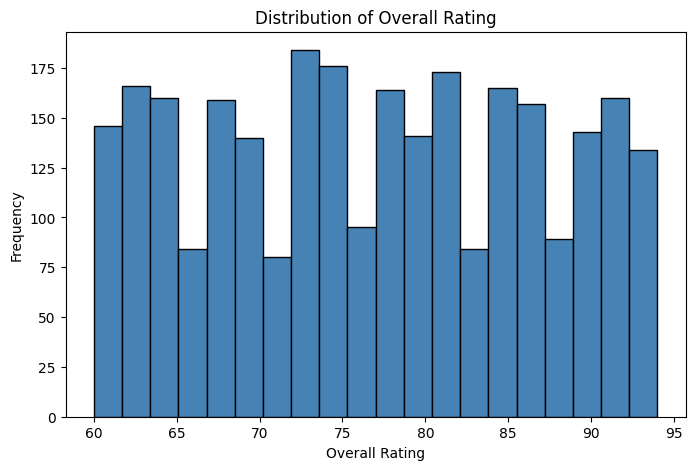

In [124]:
import matplotlib.pyplot as plt

# Histogram for overall_rating
plt.figure(figsize=(8, 5))
plt.hist(df_original['overall_rating'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Overall Rating')
plt.xlabel('Overall Rating')
plt.ylabel('Frequency')
plt.show()

# Interpretation: The distribution of overall_rating is roughly uniform/spread across
# all rating levels, meaning the dataset contains players of all skill levels equally.

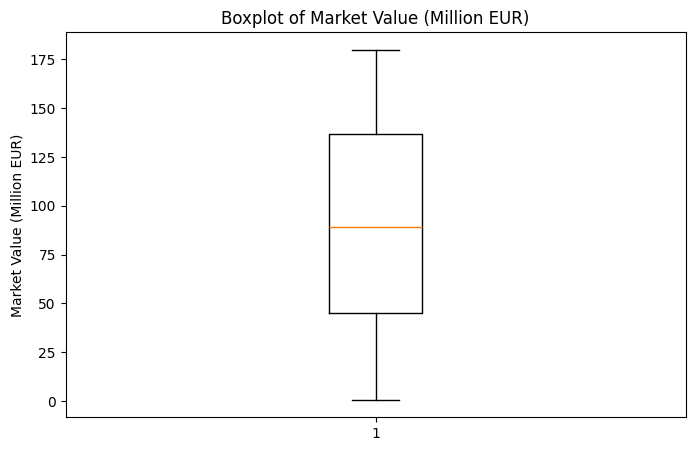

In [125]:
# Boxplot for market_value_million_eur
plt.figure(figsize=(8, 5))
plt.boxplot(df_original['market_value_million_eur'], vert=True)
plt.title('Boxplot of Market Value (Million EUR)')
plt.ylabel('Market Value (Million EUR)')
plt.show()

# Justification: Market value is the most business-relevant feature.
# The boxplot reveals the spread, median, and any outliers in player valuations.

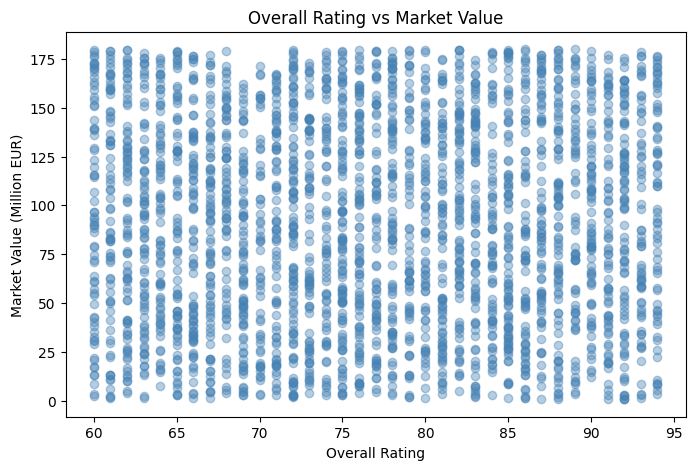

In [126]:
# Scatterplot between overall_rating and market_value_million_eur
plt.figure(figsize=(8, 5))
plt.scatter(df_original['overall_rating'], df_original['market_value_million_eur'], alpha=0.4, color='steelblue')
plt.title('Overall Rating vs Market Value')
plt.xlabel('Overall Rating')
plt.ylabel('Market Value (Million EUR)')
plt.show()

# Interpretation: There is no strong linear relationship between overall_rating
# and market_value, suggesting market value depends on more than just skill rating.

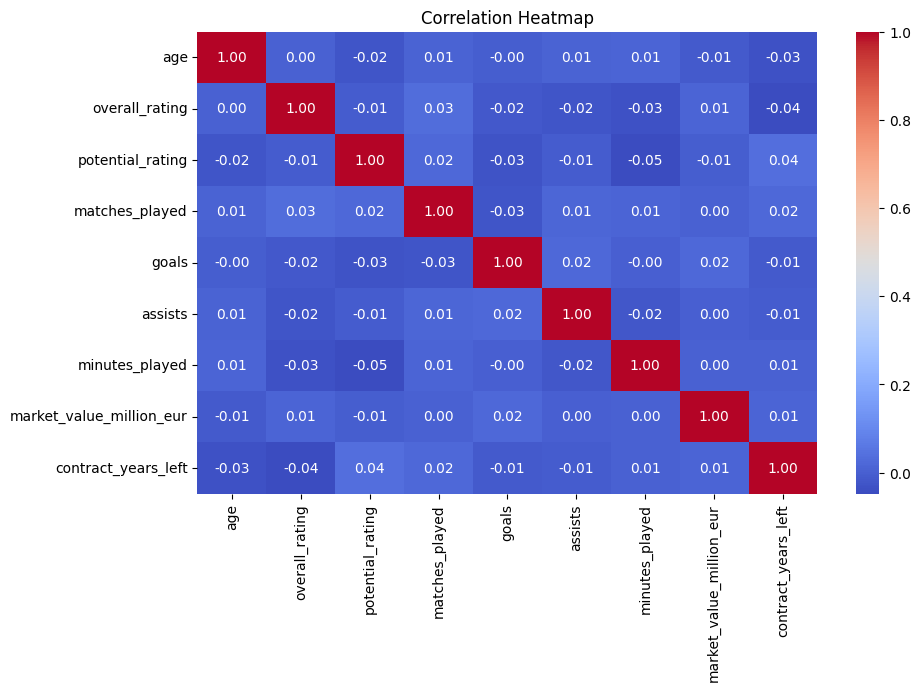

In [127]:
import seaborn as sns

numerical_cols = ['age', 'overall_rating', 'potential_rating', 'matches_played',
                  'goals', 'assists', 'minutes_played', 'market_value_million_eur', 'contract_years_left']

plt.figure(figsize=(10, 6))
sns.heatmap(df_original[numerical_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.show()

# Interpretation:
# 1. goals and assists have a slight positive correlation — creative players tend to contribute both.
# 2. age and contract_years_left show a slight negative correlation — older players tend to have fewer years left.

Average market value per position:
position
GK     86.734858
CM     88.290464
LB     88.543282
RB     90.771014
CDM    91.684918
CB     91.716190
LW     91.870884
ST     92.074863
RW     93.504949
Name: market_value_million_eur, dtype: float64


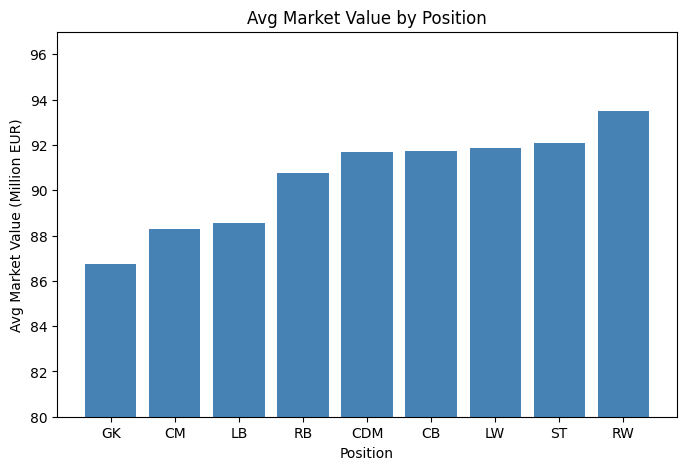

In [128]:
import matplotlib.pyplot as plt

# Insight: Attacking positions (RW, ST) command higher market values than defensive ones (GK, CM)
insight_a = df_original.groupby('position')['market_value_million_eur'].mean().sort_values()
print("Average market value per position:")
print(insight_a)

# Numerically, RW players average ~93.5M EUR while GK players average ~86.7M EUR.
# This 7.8M difference suggests attacking players are valued higher in the transfer market,
# likely due to their direct contribution to goals and assists which are
# more easily measurable and marketable than defensive contributions.

plt.figure(figsize=(8, 5))
plt.bar(insight_a.index, insight_a.values, color='steelblue')
plt.title('Avg Market Value by Position')
plt.xlabel('Position')
plt.ylabel('Avg Market Value (Million EUR)')
plt.ylim(80, 97)
plt.show()

In [129]:
# Insight: Injury-prone players play more matches and score more goals
insight_b = df_original.groupby('injury_prone')[['matches_played', 'goals', 'assists']].mean()
print("Average matches, goals, assists by injury prone status:")
print(insight_b)

# Injury-prone players average 27.6 matches vs 26.98 for non-injury-prone,
# and also score slightly more goals (19.4 vs 19.2) and get more assists (12.3 vs 11.9).
# This suggests that injury-prone players tend to be high-intensity players
# who play aggressively, leading to both higher performance and higher injury risk.

Average matches, goals, assists by injury prone status:
              matches_played      goals    assists
injury_prone                                      
No                 26.983529  19.210824  11.913882
Yes                27.614815  19.422222  12.333333


In [130]:
# Counter-intuitive: Transfer risk level has almost no relationship with any performance metric

insight_c = df_original.groupby('transfer_risk_level')[['overall_rating', 'market_value_million_eur', 'goals']].mean()
print("Average stats per transfer risk level:")
print(insight_c)

# Intuitively one would expect High transfer risk players to have lower ratings or value.
# However, overall_rating (High=76.8, Low=76.8, Medium=77.0), market value, and goals
# are nearly identical across all risk levels. This suggests transfer risk in this dataset
# is driven by factors beyond performance stats alone, such as club strategy or external factors.

Average stats per transfer risk level:
                     overall_rating  market_value_million_eur      goals
transfer_risk_level                                                     
High                      76.797853                 89.351914  19.032200
Low                       76.779200                 90.545632  19.271200
Medium                    77.016145                 91.275116  19.379415


In [131]:
# Recommendation: Clubs should invest in attacking players (RW, ST, LW)
# as they yield the highest market values and best resale potential.

insight_d = df_original.groupby('position')['market_value_million_eur'].mean().sort_values(ascending=False)
print("Market value ranking by position:")
print(insight_d)

# The top 3 highest valued positions are RW (93.5M), ST (92.1M), and LW (91.9M).
# Clubs looking to maximize squad value should prioritize signing young attackers
# with high potential ratings, as these players appreciate in value faster
# and can be resold at a profit compared to goalkeepers or defensive midfielders.

Market value ranking by position:
position
RW     93.504949
ST     92.074863
LW     91.870884
CB     91.716190
CDM    91.684918
RB     90.771014
LB     88.543282
CM     88.290464
GK     86.734858
Name: market_value_million_eur, dtype: float64


In [132]:
# New feature: performance_score — combines goals, assists, and matches_played
# to give a single measure of a player's overall contribution on the pitch
# Only calculate for players who have played at least 1 match

df_original['performance_score'] = df_original.apply(
    lambda row: (row['goals'] + row['assists']) / row['matches_played']
    if row['matches_played'] > 0 else 0, axis=1
)

print("Sample of new feature:")
print(df_original[['player_name', 'goals', 'assists', 'matches_played', 'performance_score']].head(10))

print("\nPerformance Score stats:")
print(df_original['performance_score'].describe())

Sample of new feature:
  player_name  goals  assists  matches_played  performance_score
0    Player_1      6       14               8           2.500000
1    Player_2      3       18              19           1.105263
2    Player_3     12       15              34           0.794118
3    Player_4     18       13              35           0.885714
4    Player_5      6        6              41           0.292683
5    Player_6      9        7              35           0.457143
6    Player_7     24        6              53           0.566038
7    Player_8     34       17               8           6.375000
8    Player_9     24       23              21           2.238095
9   Player_10     28        5               0           0.000000

Performance Score stats:
count    2800.000000
mean        2.683859
std         5.556941
min         0.000000
25%         0.648649
50%         1.125000
75%         2.235294
max        60.000000
Name: performance_score, dtype: float64


In [133]:
# Check if performance_score varies across transfer risk levels
print("Avg performance_score per transfer risk level:")
print(df_original.groupby('transfer_risk_level')['performance_score'].mean())

# performance_score combines goals and assists per match into one value,
# capturing a player's efficiency rather than raw totals.
# A player with 10 goals in 10 matches is more valuable than one with
# 10 goals in 40 matches. This ratio-based feature reduces noise from
# players with varying match counts and may help a classification model
# better distinguish transfer risk levels than using goals and matches separately.

Avg performance_score per transfer risk level:
transfer_risk_level
High      2.876525
Low       2.541497
Medium    2.754749
Name: performance_score, dtype: float64


#Summary

## Dataset Overview
- Dataset: FIFA Player Performance and Market Value
- 2800 players, 16 features
- Target variable: transfer_risk_level (Low 44.6%, Medium 35.4%, High 20%)
- No missing values or duplicates found

## Data Preparation
- Filtered players with overall_rating >= 70 (2800 → 2002 players)
- Applied Label Encoding on injury_prone and One-Hot Encoding on nationality, club, position
- Normalized all numerical features using StandardScaler
- Divided market_value into 5 equal-width bins — evenly distributed (~540-593 per bin)
- No features removed due to multicollinearity — all correlations near 0
- Applied Stratified Sampling — class proportions preserved perfectly after sampling

## Key Insights
1. Attacking positions (RW, ST, LW) have the highest average market values (~91-93M EUR) while GK has the lowest (~86M EUR)
2. Injury-prone players play more matches and contribute more goals and assists than non-injury-prone players
3. Transfer risk level has almost no relationship with performance stats — overall rating is nearly identical across all risk levels (~77)
4. Clubs should prioritize signing young attackers with high potential to maximize squad value and minimize transfer risk

## Feature Engineering
- Created performance_score = (goals + assists) / matches_played
- Captures player efficiency per match rather than raw totals
- Players with 0 matches assigned score of 0 to avoid division errors

In [134]:
# Final summary statistics
print("=== DATASET SUMMARY ===")
print(f"Total players: {df_original.shape[0]}")
print(f"Total features: {df_original.shape[1]}")
print(f"\nTarget variable distribution:")
print(df_original['transfer_risk_level'].value_counts())
print(f"\nMissing values: {df_original.isnull().sum().sum()}")
print(f"Duplicates: {df_original.duplicated().sum()}")

print("\n=== KEY STATS ===")
print(f"Avg market value: {df_original['market_value_million_eur'].mean():.2f}M EUR")
print(f"Avg overall rating: {df_original['overall_rating'].mean():.2f}")
print(f"Avg age: {df_original['age'].mean():.2f}")
print(f"Top position by market value: {df_original.groupby('position')['market_value_million_eur'].mean().idxmax()}")
print(f"Avg performance score: {df_original['performance_score'].mean():.2f}")

=== DATASET SUMMARY ===
Total players: 2800
Total features: 17

Target variable distribution:
transfer_risk_level
Low       1250
Medium     991
High       559
Name: count, dtype: int64

Missing values: 0
Duplicates: 0

=== KEY STATS ===
Avg market value: 90.57M EUR
Avg overall rating: 76.87
Avg age: 27.95
Top position by market value: RW
Avg performance score: 2.68
